<a href="https://colab.research.google.com/github/stacykeago/fundamentals-of-data-analytics/blob/main/FDA_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Define the question:


# Metric of success
The likelihood of a claim being rejected could be evaluated based on several key performance indicators (KPIs) commonly used in machine learning classification tasks.
1. Accuracy
2. Precision
3. Recall (Sensitivity)
4. F1 Score
5. Area Under the ROC Curve (AUC-ROC)
6. Confusion Matrix

Resources that support this analysis
1. [Business Insights & Recommendations](https://docs.google.com/document/d/1q9gwblcG5X_Cm1P03Y4Zzbr2ue-CVVN8ecXmyi_yRAM/edit?usp=sharing)
2.

# Data used:
1. [Path to data ](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv)

# a. EXPLORATORY DATA ANALYSIS (EDA)

## 1.0 Import the libraries to be used

In [29]:
import numpy as np # for linear algebra
import pandas as pd # for data processing
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
from sklearn.preprocessing import LabelEncoder # the libraries for label encoding
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


## 2.0 Upload Dataset

In [2]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv'

auto = pd.read_csv(url, header=None)

# 2. Define the correct column names for this specific IBM dataset
headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
           "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

# 3. Assign the header list to your dataframe
auto.columns = headers

# preview 10 rows
auto.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


### Column names

In [3]:
auto.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

In [4]:
# 1. Replace the actual missing data symbol "?" with NaN
auto.replace("?", np.nan, inplace=True)

# 2. Drop rows only if the price is missing
auto.dropna(subset=["price"], axis=0, inplace=True)

# 3. Fix the data types so you can do math
auto[["bore", "stroke", "peak-rpm", "horsepower", "normalized-losses"]] = auto[["bore", "stroke", "peak-rpm", "horsepower", "normalized-losses"]].astype("float")
auto["price"] = auto["price"].astype("float")

### 2.1 Number of rows and columns



In [5]:
# Print number of rows and columns
print(f"Rows: {auto.shape[0]}, Columns: {auto.shape[1]}")

Rows: 201, Columns: 26


### 2.2 Data types in each column

### 2.3 Basic info of the data

In [6]:
# Display basic information about the columns
print(auto.info())

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       199 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non-null

In [7]:
for col in auto.columns:
    count = auto[col].astype(str).str.contains(r'[^a-zA-Z0-9\s.]', na=False).sum()
    if count > 0:
        print(f"Column '{col}' has {count} rows with symbols.")

Column 'symboling' has 25 rows with symbols.
Column 'make' has 11 rows with symbols.


In [8]:
auto.dtypes

,0
symboling,int64
normalized-losses,float64
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


### 2.4 Null values / missing values




In [9]:
# To check for Null values to ensures the integrity of your dataset.
auto.isnull().sum()

,0
symboling,0
normalized-losses,37
make,0
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


No null values in the auto dataset

### 2.5 Duplicates

In [10]:
#check for duplicates : Duplicates are noise to the data
np.sum(auto.duplicated())

np.int64(0)

### 2.6 Unique features in the data

In [11]:
# count of unique values for each column in the DataFrame.
auto.nunique()

,0
symboling,6
normalized-losses,51
make,22
fuel-type,2
aspiration,2
num-of-doors,2
body-style,5
drive-wheels,3
engine-location,2
wheel-base,52


### 2.7 Outliers

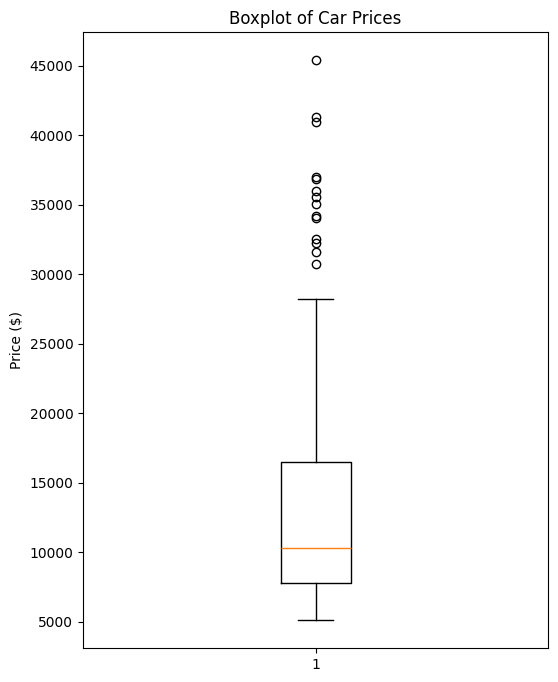

In [12]:
import matplotlib.pyplot as plt

# 1. Convert price to numeric so matplotlib can actually plot it
auto['price'] = pd.to_numeric(auto['price'], errors='coerce')

# 2. Drop rows with missing prices so the boxplot doesn't break
clean_prices = auto['price'].dropna()

# 3. Create the boxplot
plt.figure(figsize=(6, 8))
plt.boxplot(clean_prices)
plt.title('Boxplot of Car Prices')
plt.ylabel('Price ($)')
plt.show()

## statistical summary

In [26]:
auto.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,164.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,197.000000,201.000000,199.000000,199.000000,201.000000,201.000000,201.000000
mean,0.840796,122.000000,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353
std,1.254802,35.442168,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.270793,0.319256,4.004965,37.553843,480.521824,6.423220,6.815150,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


# b. Univariate Analysis

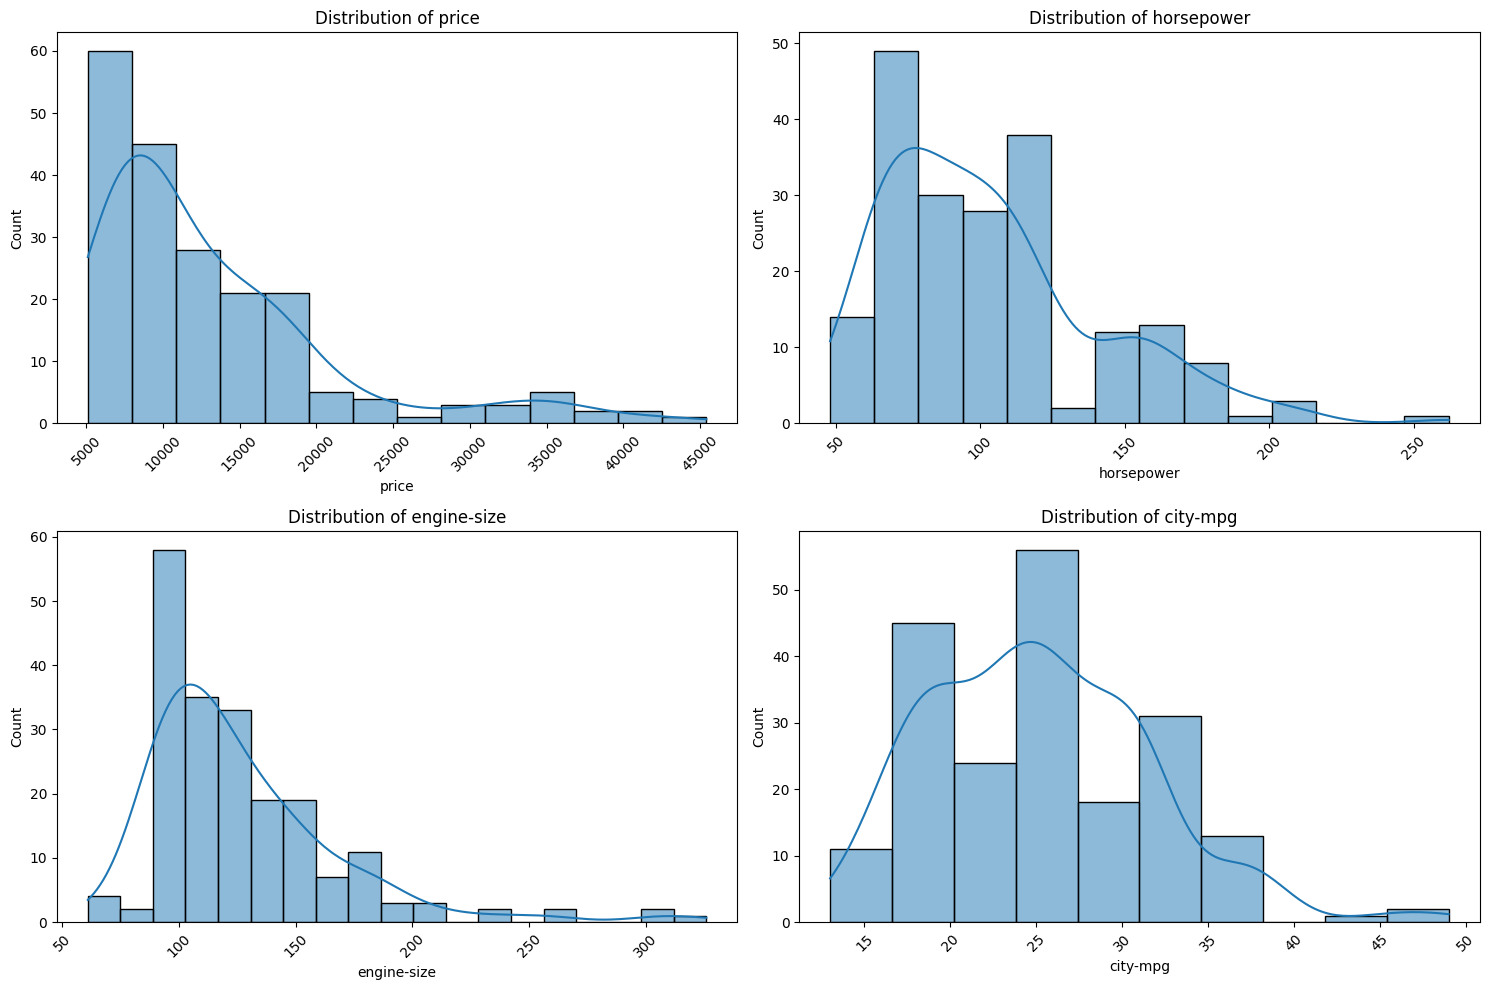

In [13]:
# 2. Define the columns to plot
col_dict = {"price": 1, "horsepower": 2, "engine-size": 3, "city-mpg": 4}

plt.figure(figsize=(15, 10))

# 3. Loop through your actual auto dataframe
for variable, i in col_dict.items():
    plt.subplot(2, 2, i)  # Adjusted grid to 2x2 for 4 variables
    sns.histplot(auto[variable].dropna(), kde=True)
    plt.title(f"Distribution of {variable}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# c. Bivariate Analysis

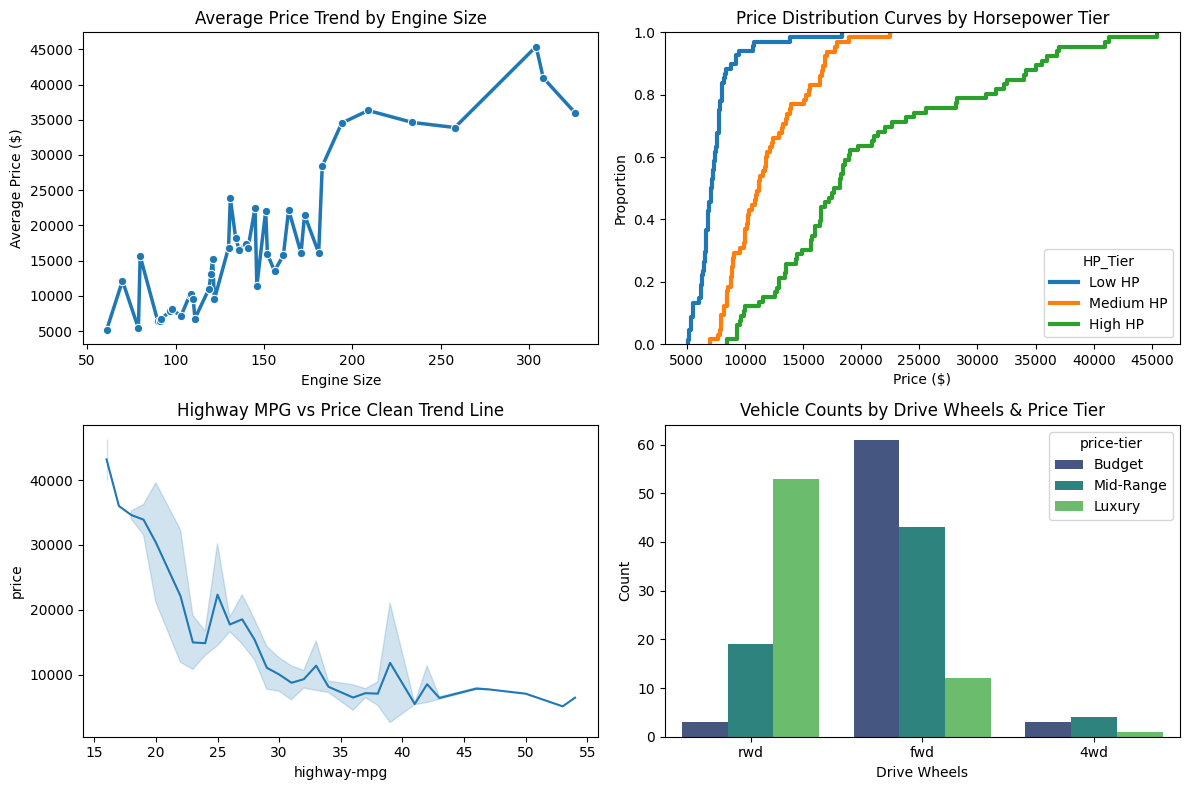

In [14]:
# Ensure target columns are numeric
num_cols = ["price", "horsepower", "engine-size", "highway-mpg"]
for col in num_cols:
    auto[col] = pd.to_numeric(auto[col], errors="coerce")

# Drop rows with NaN in the plotting columns to prevent errors
clean_auto = auto.dropna(subset=num_cols + ["drive-wheels"]).copy()

# Create categorical tiers for the ECDF plot
clean_auto['HP_Tier'] = pd.qcut(clean_auto['horsepower'], q=3, labels=["Low HP", "Medium HP", "High HP"])

# Create price brackets for the Count Plot
clean_auto['price-tier'] = pd.qcut(clean_auto['price'], q=3, labels=["Budget", "Mid-Range", "Luxury"])

plt.figure(figsize=(12, 8))

# Plot 1: Line Plot with Aggregated Markers
plt.subplot(2, 2, 1)
sns.lineplot(data=clean_auto, x="engine-size", y="price", marker="o", errorbar=None, linewidth=2.5)
plt.title("Average Price Trend by Engine Size")
plt.xlabel("Engine Size")
plt.ylabel("Average Price ($)")

# Plot 2: Empirical Cumulative Distribution Function (ECDF) for Horsepower Tiers
plt.subplot(2, 2, 2)
sns.ecdfplot(data=clean_auto, x="price", hue="HP_Tier", linewidth=3)
plt.title("Price Distribution Curves by Horsepower Tier")
plt.xlabel("Price ($)")

# Plot 3: Line Plot (Aggregated trend line with confidence interval shading)
plt.subplot(2, 2, 3)
sns.lineplot(data=clean_auto, x="highway-mpg", y="price", errorbar="sd")
plt.title("Highway MPG vs Price Clean Trend Line")

# Plot 4: Count Plot (Drive Wheels vs Price Tier)
plt.subplot(2, 2, 4)
sns.countplot(
    data=clean_auto,
    x="drive-wheels",
    hue="price-tier",
    palette="viridis"
)
plt.title("Vehicle Counts by Drive Wheels & Price Tier")
plt.xlabel("Drive Wheels")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# d. Multivariate Analysis

In [15]:
# Define the relevant numeric columns
numeric_cols = ["price", "engine-size", "horsepower", "highway-mpg", "curb-weight", "width"]

# Ensure columns are numeric
for col in numeric_cols:
    auto[col] = pd.to_numeric(auto[col], errors="coerce")

# Calculate the correlation matrix
corr = auto[numeric_cols].corr()
corr

,price,engine-size,horsepower,highway-mpg,curb-weight,width
price,1.000000,0.872335,0.810533,-0.704692,0.834415,0.751265
engine-size,0.872335,1.000000,0.822713,-0.679571,0.849072,0.729436
horsepower,0.810533,0.822713,1.000000,-0.804596,0.758063,0.615315
highway-mpg,-0.704692,-0.679571,-0.804596,1.000000,-0.794889,-0.680635
curb-weight,0.834415,0.849072,0.758063,-0.794889,1.000000,0.866201
width,0.751265,0.729436,0.615315,-0.680635,0.866201,1.000000


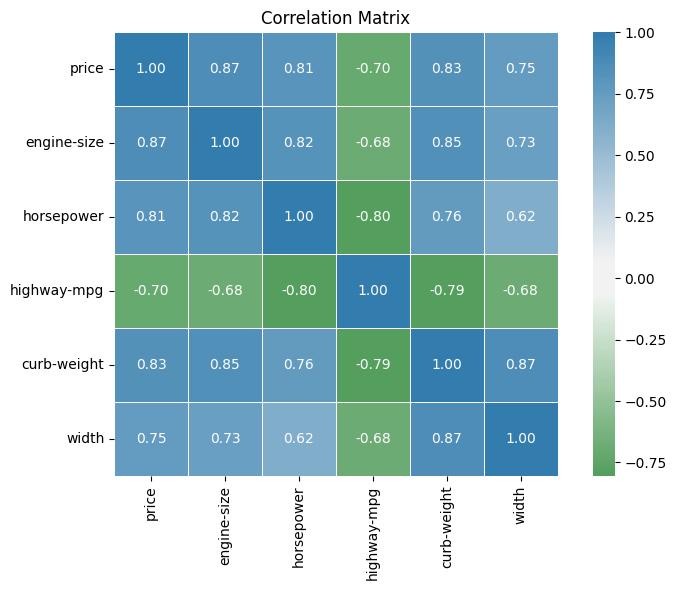

In [28]:
# Select the most relevant numeric columns
relevant_cols = ["price", "engine-size", "horsepower", "highway-mpg", "curb-weight", "width"]

# Force columns to be numeric
for col in relevant_cols:
    auto[col] = pd.to_numeric(auto[col], errors="coerce")

# Compute the correlation matrix
corr_matrix = auto[relevant_cols].corr()

# Create a custom palette: Green (negative), Orange/Yellow (mid), Blue (positive)
custom_cmap = sns.diverging_palette(130, 240, s=85, l=50, sep=20, center="light", as_cmap=True)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=custom_cmap,  # Applied custom green-orange-blue palette
    center=0,          # Centers the colormap at 0 correlation
    fmt=".2f",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png")

# Skewness

In [17]:
# 1. Select and clean numeric features
features = ["engine-size", "horsepower", "highway-mpg", "curb-weight", "width"]
for col in features:
    auto[col] = pd.to_numeric(auto[col], errors="coerce")

# Drop missing values for calculations
df_clean = auto[features].dropna().copy()

# --- SKEWNESS ---
print("--- Feature Skewness ---")
print(df_clean.skew())
print("\n*Note: Highly skewed features (> |1|) may need log transformation.*")



--- Feature Skewness ---
engine-size    1.973596
horsepower     1.141584
highway-mpg    0.548218
curb-weight    0.700441
width          0.881262
dtype: float64

*Note: Highly skewed features (> |1|) may need log transformation.*


# VIF

In [18]:
# --- VIF (Multicollinearity) ---
print("\n--- Variance Inflation Factor (VIF) ---")
# Add constant intercept for VIF calculation
X = df_clean.copy()
X['intercept'] = 1

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns[:-1] # Exclude intercept row from output display
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns) - 1)]
print(vif_data)
print("\n*Note: VIF > 5 indicates high multicollinearity.*")




--- Variance Inflation Factor (VIF) ---
       Feature       VIF
0  engine-size  5.590920
1   horsepower  5.040715
2  highway-mpg  4.178531
3  curb-weight  8.585370
4        width  4.122090

*Note: VIF > 5 indicates high multicollinearity.*


# Normalization

In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Target variable
target_col = "price"

# 2. Separate relevant numeric features from categorical text features
numeric_features = ["engine-size", "horsepower", "highway-mpg", "curb-weight", "width"]

# 3. Clean and convert to numeric types
for col in numeric_features + [target_col]:
    auto[col] = pd.to_numeric(auto[col], errors="coerce")

# 4. Drop missing rows across selected variables to avoid scaling errors
clean_auto = auto.dropna(subset=numeric_features + [target_col]).copy()

# 5. Separate features (X) and target label (y)
X = clean_auto[numeric_features]
y = clean_auto[target_col]

# 6. Initialize and apply the MinMaxScaler
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# 7. Convert back to a DataFrame for clean visualization
X_normalized_df = pd.DataFrame(X_normalized, columns=numeric_features, index=clean_auto.index)

# Print results
print("--- First 5 Rows of Normalized Features (Scaled 0 to 1) ---")
print(X_normalized_df.head())

print("\n--- Associated Target Labels (Price) ---")
print(y.head())

--- First 5 Rows of Normalized Features (Scaled 0 to 1) ---
   engine-size  horsepower  highway-mpg  curb-weight     width
0     0.260377    0.294393     0.289474     0.411171  0.324786
1     0.260377    0.294393     0.289474     0.411171  0.324786
2     0.343396    0.495327     0.263158     0.517843  0.444444
3     0.181132    0.252336     0.368421     0.329325  0.504274
4     0.283019    0.313084     0.157895     0.518231  0.521368

--- Associated Target Labels (Price) ---
0    13495.0
1    16500.0
2    16500.0
3    13950.0
4    17450.0
Name: price, dtype: float64


## Feature selection
• What features seem most related to price?

In [20]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

## Feature Scaling

# HYPOTHESIS TESTING
1. Does higher horsepower always mean higher price?


# Linear Regression

# Random Forest